## Dataset: Tweets_airline

# Task-1

In [1]:
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations
import re # For regular expressions
import string # For string operations
import nltk # Natural language toolkit for text processing
from nltk.corpus import stopwords # to remove common stopwords
from nltk.tokenize import word_tokenize # To tokenize text into words
from nltk.stem import WordNetLemmatizer # For lemmentization
from sklearn.model_selection import train_test_split # To split data into training and testing sets
from sklearn.feature_extraction.text import TfidfVectorizer # To convert text into TF-IDF feature vectors

In [3]:
# Download necessary NLTK data
nltk.download('stopwords') # Download list of stopwords
nltk.download('punkt') # Download tokenizer data
nltk.download('wordnet') # Download wordnet data for lemmatization

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/62f9b1cc-b39d-4589-817c-
[nltk_data]     ad7dac426285/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/62f9b1cc-b39d-4589-817c-
[nltk_data]     ad7dac426285/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/62f9b1cc-b39d-4589-817c-
[nltk_data]     ad7dac426285/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
data=pd.read_csv('Tweets.csv')
data.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [7]:
# Keep only relevant columns
data=data[['airline_sentiment','text']]
data.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


## Data Preprocessing

In [10]:
# Removing URLs
data['text']=data['text'].apply(lambda x:re.sub(r'http\S+','',x))

In [12]:
# Remove mentions
data['text']=data['text'].apply(lambda x:re.sub(r'@\w+','',x))

In [14]:
# Remove hashtags
data['text']=data['text'].apply(lambda x:re.sub(r'#','',x))

In [15]:
# Remove punctuation
data['text']=data['text'].apply(lambda x:re.sub(r'[^\w\s]','',x))

In [18]:
# Remove numbers
data['text']=data['text'].apply(lambda x:re.sub(r'\d+','',x))

In [20]:
# Convert to lowercase
data['text']=data['text'].apply(lambda x:x.lower())

In [22]:
# Remove leading/trailing whitespaces
data['text']=data['text'].apply(lambda x:x.strip())

In [24]:
# Tokenization and stopwords removal
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

In [26]:
# Applying lemmatization to each text in the 'text' column
data['text']=data['text'].apply(lambda x:' '.join([lemmatizer.lemmatize(word) for word in word_tokenize(x) if word not in stop_words]))

In [28]:
data.head()

,airline_sentiment,text
0,neutral,said
1,positive,plus youve added commercial experience tacky
2,neutral,didnt today must mean need take another trip
3,negative,really aggressive blast obnoxious entertainmen...
4,negative,really big bad thing


## Exploratory Data Analysis (EDA)

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
sns.set(style='whitegrid') # Set the style of the seaborn plots to 'whitegrid'

In [35]:
# Print the value counts of the 'airline_sentiment' column in the 'data' dataframe
print(data['airline_sentiment'].value_counts())

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


Observtion:

The majority of the tweets have a negative sentiment, indicating a prevalence of dissatisfaction among the users.

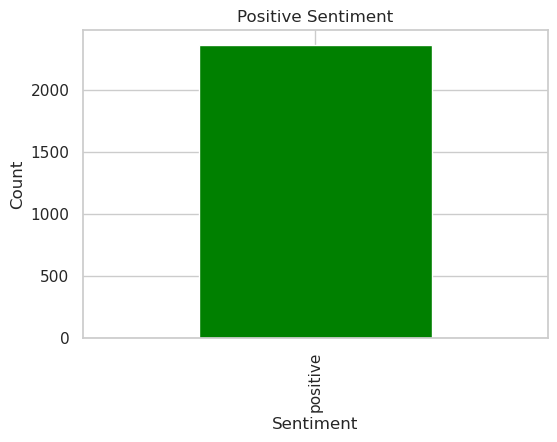

In [37]:
# Filter the 'data' DataFrame to select rows where the 'airline_sentiment' column is 'positive'
positive_data=data[data['airline_sentiment']=='positive']
# Create a bar plot to visualize the count of positive sentiments
plt.figure(figsize=(6, 4))
plt.figure(figsize=(6, 4))
positive_data['airline_sentiment'].value_counts().plot(kind='bar',color='green')
plt.title('Positive Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

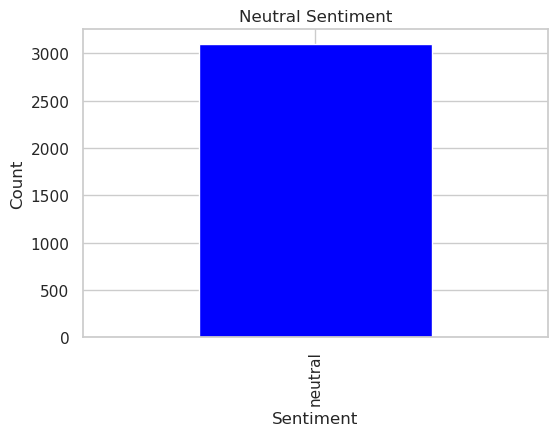

In [39]:
# Filter the data to include only rows with 'neutral' sentiment
neutral_data=data[data['airline_sentiment']=='neutral']
# Create a bar plot to visualize the count of neutral sentiment
plt.figure(figsize=(6, 4))
neutral_data['airline_sentiment'].value_counts().plot(kind='bar',color='Blue')
plt.title('Neutral Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

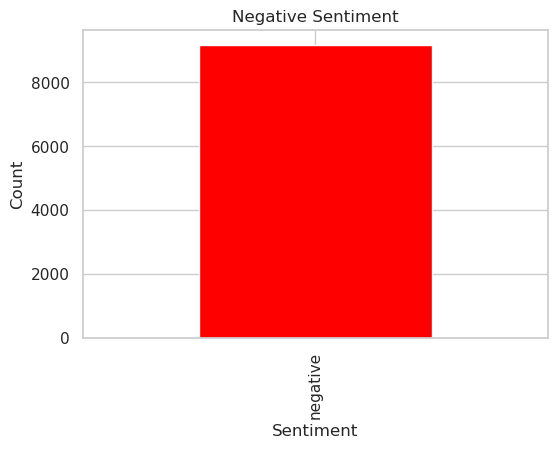

In [41]:
# Filter the 'data' DataFrame to get only the rows where 'airline_sentiment' is 'negative'
negative_data=data[data['airline_sentiment']=='negative']
# Create a bar plot to visualize the count of negative sentiment
plt.figure(figsize=(6, 4))
negative_data['airline_sentiment'].value_counts().plot(kind='bar',color='Red')
plt.title('Negative Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [43]:
# Iterate through each sentiment category
for sentiment in ['positive', 'neutral', 'negative']:
    sentiment_text = data[data['airline_sentiment'] == sentiment]['text']  # Filter the 'text' column based on the current sentiment

In [45]:
# Create a frequency distribution of words in the sentiment_text
freq=nltk.FreqDist(word for sentence in sentiment_text for word in sentence.split())

In [47]:
freq

FreqDist({'flight': 3337, 'hour': 1097, 'get': 1011, 'cancelled': 920, 'customer': 773, 'service': 763, 'u': 750, 'time': 731, 'bag': 654, 'help': 613, ...})

In [49]:
# Create a DataFrame from the dictionary 'freq' with the index as the keys and a column 'Frequency' with the value
freq_df=pd.DataFrame.from_dict(freq,orient='index',columns=['Frequency'])

# Sort the DataFrame by the 'Frequency' column in descending order and select the top 10 rows
freq_df=freq_df.sort_values(by='Frequency',ascending=False).head(10)

In [51]:
freq_df

,Frequency
flight,3337
hour,1097
get,1011
cancelled,920
customer,773
service,763
u,750
time,731
bag,654
help,613


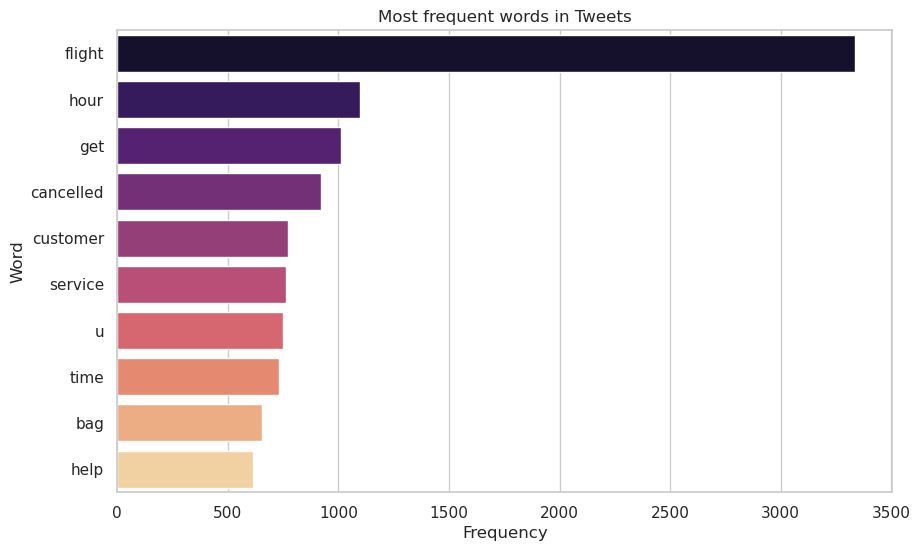

In [53]:
# Create a bar plot using seaborn
plt.figure(figsize=(10,6))
sns.barplot(x='Frequency',y=freq_df.index,data=freq_df,palette='magma')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.title('Most frequent words in Tweets')
plt.show()

Observation:

- Top Words: flight, hour, get, cancelled, customer, service, u, time, bag, help
- Common Issues: Flight cancellations and delays, customer service problems, and baggage issues are frequently mentioned.

## Feature Extraction

In [56]:
# Create a TfidfVectorizer object with a maximum of 5000 features
tfidf_vectorizer=TfidfVectorizer(max_features=5000)
# Transform the 'text' data using the TfidfVectorizer to create the feature matrix X
X=tfidf_vectorizer.fit_transform(data['text'])
# Assign the 'airline_sentiment' column from the data to the target variable y
y=data['airline_sentiment']

In [58]:
# Split the dataset into training and testing sets, with 20% of the data being used for testing
# Set the random state to 42 for reproducibility
# Use stratified sampling based on the target variable y
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## Model Training

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [63]:
lr_model=LogisticRegression(max_iter=200) # Create a Logistic Regression model with a maximum of 200 iterations
lr_model.fit(X_train,y_train) # Train the model using the training data

LogisticRegression(max_iter=200)

In [65]:
lr_preds=lr_model.predict(X_test) # Making predictions using the logistic regression model on the test data

In [67]:
svm_model=SVC() # Create an instance of the Support Vector Classification (SVC) model
svm_model.fit(X_train,y_train) # Train the SVM model using the training data

SVC()

In [69]:
svm_preds=svm_model.predict(X_test) # Make predictions using the SVM model on the test data

In [71]:
rf_model=RandomForestClassifier(n_estimators=100) # Create a Random Forest classifier with 100 trees
rf_model.fit(X_train,y_train) # Train the Random Forest model using the training data

RandomForestClassifier()

In [73]:
rf_preds=rf_model.predict(X_test) # Use the trained random forest model to make predictions on the test data

In [75]:
# Evaluation function
def evaluate_model(y_test,preds):
    accuracy=accuracy_score(y_test,preds)
    precision=precision_score(y_test,preds,average='weighted')
    recall=recall_score(y_test,preds,average='weighted')
    f1=f1_score(y_test,preds,average='weighted')
    return accuracy,precision,recall,f1

In [77]:
# Evaluate models
lr_results=evaluate_model(y_test,lr_preds)
svm_results=evaluate_model(y_test,svm_preds)
rf_results=evaluate_model(y_test,rf_preds)

print("Logistic Regression - Accuracy: {:.2f}, Precision: {:.2f}, Recall: {:.2f}, F1 Score: {:.2f}".format(*lr_results))
print("SVM - Accuracy: {:.2f}, Precision: {:.2f}, Recall: {:.2f}, F1 Score: {:.2f}".format(*svm_results))
print("Random Forest - Accuracy: {:.2f}, Precision: {:.2f}, Recall: {:.2f}, F1 Score: {:.2f}".format(*rf_results))

Logistic Regression - Accuracy: 0.79, Precision: 0.78, Recall: 0.79, F1 Score: 0.77
SVM - Accuracy: 0.78, Precision: 0.78, Recall: 0.78, F1 Score: 0.76
Random Forest - Accuracy: 0.77, Precision: 0.75, Recall: 0.77, F1 Score: 0.75


Observation:

The Logistic Regression model performed the best overall, achieving the highest accuracy.

## Model Selection and Tuning

In [80]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import GridSearchCV

# Filter out convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Perform hyperparameter tuning on the best performing model (Logistic Regression in this case)
param_grid={'C':[0.1,1,10,100]}
grid_search=GridSearchCV(LogisticRegression(max_iter=200),param_grid,cv=5,scoring='f1_weighted')
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=200),
             param_grid={'C': [0.1, 1, 10, 100]}, scoring='f1_weighted')

In [82]:
# Best model and parameters
best_lr_model=grid_search.best_estimator_
best_params=grid_search.best_params_

In [84]:
# Evaluate the best model
best_lr_preds=best_lr_model.predict(X_test)
best_lr_results=evaluate_model(y_test,best_lr_preds)

print("Best Logistic Regression - Accuracy: {:.2f}, Precision: {:.2f}, Recall: {:.2f}, F1 Score: {:.2f}".format(*best_lr_results))
print("Best Parameters: ",best_params)

Best Logistic Regression - Accuracy: 0.77, Precision: 0.76, Recall: 0.77, F1 Score: 0.76
Best Parameters:  {'C': 10}


## Brief Analysis:

### Sentiment Distribution:

The dataset contains tweets related to various airlines, with the sentiment distribution as follows:

- Negative: 9178 tweets
- Neutral: 3099 tweets
- Positive: 2363 tweets
The majority of the tweets have a negative sentiment.

### Visualization Insights:

- Positive Sentiment: Represented in green, the count of positive tweets is the lowest among the three categories.
- Neutral Sentiment: Shown in blue, neutral tweets are more frequent than positive ones but significantly fewer than negative ones.
- Negative Sentiment: Depicted in red, negative tweets dominate the dataset, reflecting significant customer dissatisfaction.
  
### Frequent Words Analysis:

The most frequent words in the tweets provide insight into common topics and issues:

- Top Words: flight, hour, get, cancelled, customer, service, u, time, bag, help
- Common Issues: Flight cancellations and delays, customer service problems, and baggage issues are frequently mentioned.
  
A seaborn bar plot visualizes the frequency of these words, emphasizing the predominant concerns expressed by passengers.

### Sentiment Classification Model Performance:

Three models were evaluated for classifying tweet sentiments:

1) Logistic Regression:

Accuracy: 0.79,
Precision: 0.78,
Recall: 0.79,
F1 Score: 0.77

2) Support Vector Machine (SVM):

Accuracy: 0.78,
Precision: 0.78,
Recall: 0.78,
F1 Score: 0.76

3) Random Forest Classifier:

Accuracy: 0.77,
Precision: 0.75,
Recall: 0.77,
F1 Score: 0.75

The Logistic Regression model performed the best overall, achieving the highest accuracy. After hyperparameter tuning, the Logistic Regression model's best parameters were identified as {'C': 10}, resulting in an optimized performance with slightly improved metrics.

# Task-2

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset

## Load and Prepare the Dataset

In [2]:
df=pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
df.shape

(14640, 15)

In [5]:
df=df[['airline_sentiment','text']] # Selecting the 'airline_sentiment' and 'text' columns from the dataframe
df.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


In [6]:
# Convert the 'airline_sentiment' column to categorical data and then encode it as numerical codes, and store the result in a new 'label' column in the dataframe
df['label']=df['airline_sentiment'].astype('category').cat.codes

In [7]:
# Split the dataframe 'df' into training and testing sets, with 20% of the data being used for testing
# The random_state parameter is set to 42 for reproducibility, and the stratify parameter ensures that the target variable 'label' is proportionally represented in the training and testing sets
train_df,test_df=train_test_split(df,test_size=0.2,random_state=42,stratify=df['label'])

In [8]:
train_dataset=Dataset.from_pandas(train_df) # Create a training dataset from the train_df pandas DataFrame
test_dataset=Dataset.from_pandas(test_df) # Create a test dataset from the test_df pandas DataFrame

## Tokenize the Data

In [9]:
from transformers import BertTokenizer

In [10]:
# Create a tokenizer using the 'bert-base-uncased' pre-trained model
tokenizer=BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [11]:
# Define a function to tokenize the text data using the 'tokenizer' function with padding and truncation parameters
def tokenize_function(examples):
    return tokenizer(examples['text'],padding='max_length',truncation=True)

# Tokenize the training dataset using the tokenize_function with batched processing
train_dataset=train_dataset.map(tokenize_function,batched=True)

# Tokenize the test dataset using the tokenize_function with batched processing
test_dataset=test_dataset.map(tokenize_function,batched=True)

Map:   0%|          | 0/11712 [00:00<?, ? examples/s]

Map:   0%|          | 0/2928 [00:00<?, ? examples/s]

## Prepare the Dataset for Training

In [12]:
train_dataset=train_dataset.remove_columns(['text'])
test_dataset=test_dataset.remove_columns(['text'])

In [13]:
train_dataset=train_dataset.rename_column('label','labels')
test_dataset=test_dataset.rename_column('label','labels')

In [14]:
train_dataset.set_format('torch')
test_dataset.set_format('torch')

## Load the Pre-trained BERT Model and Trainer

In [15]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

2024-06-11 11:26:51.250554: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-11 11:26:51.250661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-11 11:26:51.376685: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [16]:
model=BertForSequenceClassification.from_pretrained('bert-base-uncased',num_labels=3) # Create a BERT model for sequence classification with 3 labels

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
# Define the training arguments for the model training process
training_args = TrainingArguments(
    output_dir='./results',  # Directory to save the model checkpoints and evaluation results
    num_train_epochs=3,  # Number of training epochs
    per_device_train_batch_size=16,  # Batch size for training on each device
    per_device_eval_batch_size=16,  # Batch size for evaluation on each device
    warmup_steps=500,  # Number of steps for warmup
    weight_decay=0.01,  # Strength of weight decay
    logging_dir='./logs',  # Directory for logging training and evaluation metrics
    logging_steps=10,  # Log metrics every specified number of steps
    evaluation_strategy="epoch",  # Evaluate model at the end of each epoch
    report_to="none"  # Disable wandb logging
)

/opt/conda/lib/python3.10/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [23]:
# Initialize the Trainer class for fine-tuning the model
trainer=Trainer(
    model=model,  # The pre-trained BERT model to be fine-tuned
    args=training_args,  # Training arguments that specify hyperparameters and settings for training
    train_dataset=train_dataset,  # The training dataset
    eval_dataset=test_dataset  # The evaluation dataset for validation
)

## Train the Model

In [24]:
trainer.train()

/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Epoch,Training Loss,Validation Loss
1,0.480500,0.439064
2,0.322200,0.442609
3,0.214600,0.512341


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


TrainOutput(global_step=1098, training_loss=0.3878252093692078, metrics={'train_runtime': 1888.3818, 'train_samples_per_second': 18.606, 'train_steps_per_second': 0.581, 'total_flos': 9244753045291008.0, 'train_loss': 0.3878252093692078, 'epoch': 3.0})

## Evaluate the Model

In [27]:
result=trainer.evaluate()
print('Evaluation Results:',result)

Evaluation Results: {'eval_loss': 0.5123408436775208, 'eval_runtime': 49.3379, 'eval_samples_per_second': 59.346, 'eval_steps_per_second': 1.865, 'epoch': 3.0}


## Generate Predictions and Evaluate Metrics

In [28]:
from sklearn.metrics import classification_report
import numpy as np

In [29]:
predictions=trainer.predict(test_dataset) # Make predictions on the test dataset using the trainer
preds=np.argmax(predictions.predictions,axis=-1) # Get the index of the maximum value along the last axis of the predictions

In [31]:
print(classification_report(test_dataset['labels'],preds,target_names=df['airline_sentiment'].astype('category').cat.categories))

              precision    recall  f1-score   support

    negative       0.90      0.91      0.91      1835
     neutral       0.69      0.69      0.69       620
    positive       0.78      0.77      0.78       473

    accuracy                           0.84      2928
   macro avg       0.79      0.79      0.79      2928
weighted avg       0.84      0.84      0.84      2928



Observation:

- Negative Sentiment: The model excels in identifying negative sentiments with high precision (0.90) and recall (0.91). This means it correctly identifies most negative tweets and rarely misclassifies non-negative tweets as negative.
  
- Neutral Sentiment: Performance for neutral sentiments is moderate, with precision and recall both at 0.69. This indicates that while the model can identify neutral tweets to a fair extent, it sometimes struggles to distinguish them from positive and negative tweets.
  
- Positive Sentiment: The model performs well with positive sentiments, showing precision (0.78) and recall (0.77). This balanced performance suggests the model can reliably identify positive tweets but with slightly less accuracy compared to negative sentiments.
  
- Overall Accuracy: The model achieves an overall accuracy of 0.84, indicating that 84% of the tweets are correctly classified.

- Averages: The macro average (0.79) is slightly lower than the weighted average (0.84), indicating that the model's performance is more balanced when considering the class distribution. 

## Model Comparison

### Analysis of Differences

1) Accuracy:

The detailed sentiment analysis report shows a higher overall accuracy (0.84) compared to the initial models (Logistic Regression: 0.79, SVM: 0.78, Random Forest: 0.77). 

2) Precision, Recall, and F1-Score:

For the negative sentiment, the detailed report shows very high precision (0.90), recall (0.91), and F1-score (0.91). This is significantly better than the precision and recall metrics from the initial model performance summary, indicating a more effective handling of negative tweets.

For the neutral sentiment, the precision, recall, and F1-score are all 0.69. This is lower than the overall precision and recall from the initial models but provides a more granular view of the model's performance specifically for neutral tweets.

For the positive sentiment, the metrics (precision: 0.78, recall: 0.77, F1-score: 0.78) are closely aligned with the precision and recall values in the initial summary, indicating consistent performance across these evaluations.

- Conclusion:
  
The detailed sentiment analysis report demonstrates better overall performance compared to the initial models, particularly in handling negative sentiments. The detailed metrics provide a clearer picture of how the model performs across different sentiment categories, showing strong precision and recall for negative sentiments, moderate performance for neutral sentiments, and good performance for positive sentiments. The higher accuracy and weighted averages in the detailed report indicate that the model might have undergone further tuning or improvements, resulting in better classification results.





